In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../../")

In [3]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

In [12]:
sessions = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
    # 'M103_2026_02_18_15_30',
    # 'M103_2026_02_19_15_30',
    # 'M106_2026_02_25_15_00',
    # 'M106_2026_02_26_16_00'
]

session_area_exclusions = {
    # 'M062_2025_03_20_14_00': ['VAL'],
    # 'M062_2025_03_21_14_00': ['SSp', 'CP'],
}

# Testing new dropping function

In [13]:
all_session = dsp.load_sessions_for_trial_analyses(sessions)

Loading sessions:   0%|          | 0/1 [00:00<?, ?it/s]


M062_2025_03_20_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(


['SSp_spikes', 'VAL_spikes', 'all_spikes', 'CP_spikes', 'MOp_spikes']
Resulting SSp_spikes ephys data shape is (NxT): (118, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (155, 48000)
Resulting all_spikes ephys data shape is (NxT): (34, 48000)
Resulting CP_spikes ephys data shape is (NxT): (356, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (163, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 20 trials
Otsu immobility threshold: 3.9807
Dropped 27 of 354 rows (7.63%).
  drop_trials_sem_crosses_zero: by SEM: 213  |  by value: 314  |  kept: 212/315 (67.3%)


Loading sessions: 100%|██████████| 1/1 [00:30<00:00, 30.48s/it]


Loaded 1/1 sessions successfully.


In [8]:
df_tr_dropped = dsp.drop_trials_sem_crosses_zero(df_tr)

  drop_trials_sem_crosses_zero: kept 218/270 trials (80.7%)


In [53]:
df_tr_dropped = dsp.drop_trials_sem_crosses_zero(df_tr, thresh_val=-3)
disturbances = np.sum(np.stack(df_tr_dropped.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)

  drop_trials_sem_crosses_zero: by SEM: 186  |  by value: 268  |  kept: 184/270 (68.1%)


In [8]:
df_tr_dropped = all_session['M086_2025_12_10_15_00']['td']
disturbances = np.sum(np.stack(df_tr_dropped.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)

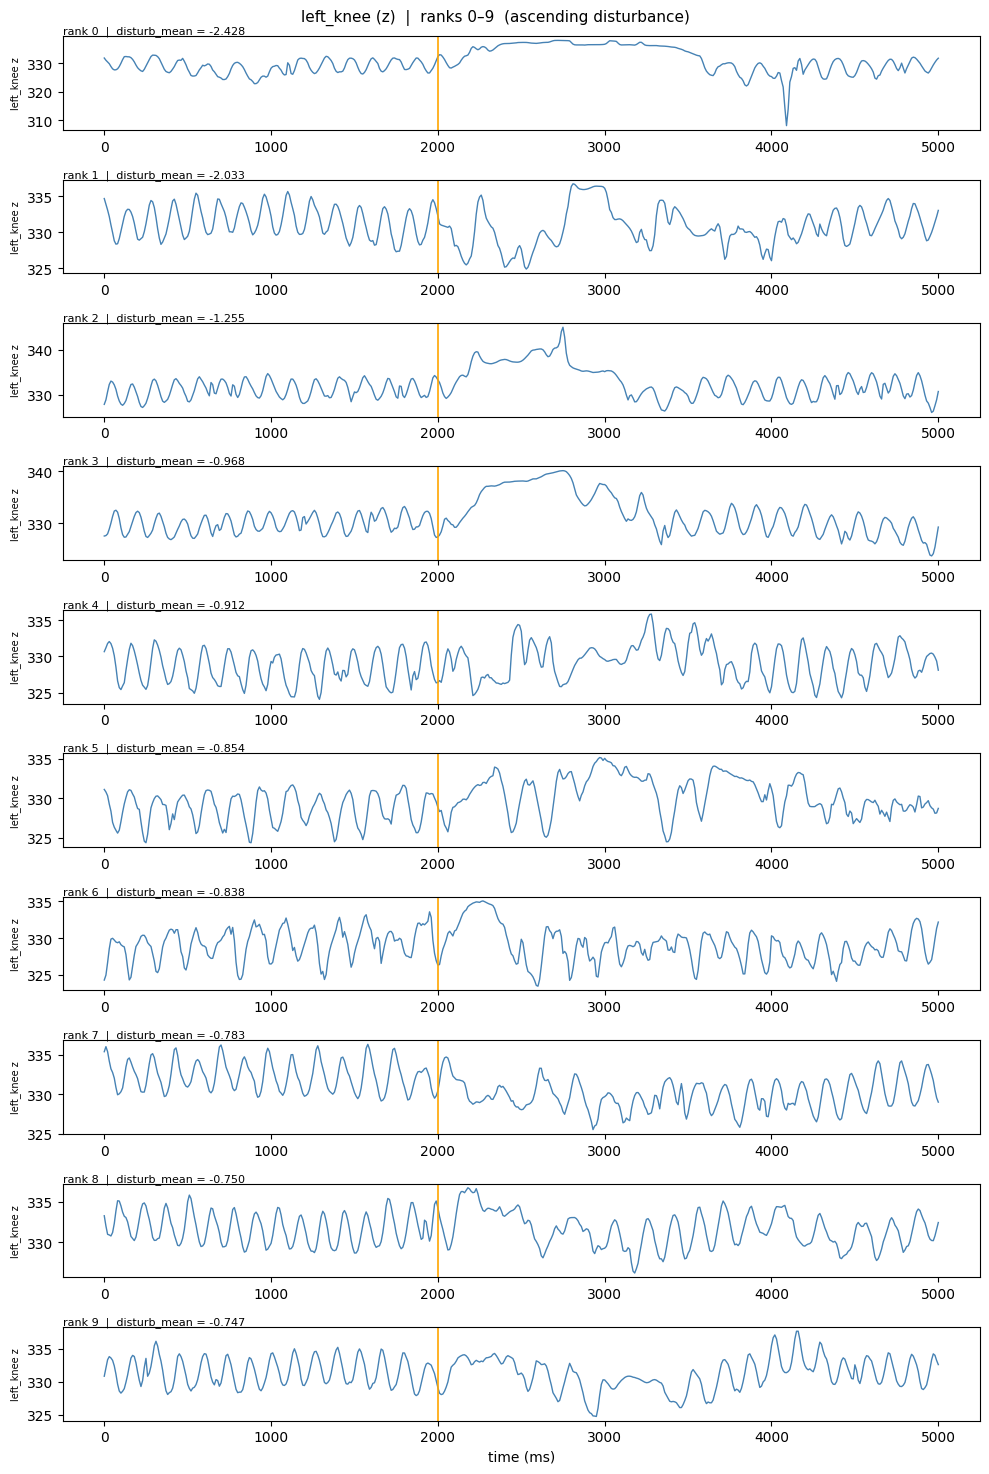

In [10]:
# --- Parameters ---
PAGE      = 0
PAGE_SIZE = 10
KEYPOINT  = 'left_knee'   # any name in Params.oscillating_key_points
DIM       = 2              # 0=x, 1=y, 2=z (vertical)
# ------------------

kp_idx    = list(Params.oscillating_key_points).index(KEYPOINT)
col_idx   = kp_idx * 3 + DIM
dim_label = ['x', 'y', 'z'][DIM]

# dstrb_idx sorts trials ascending (most disturbed first = most negative)
start = PAGE * PAGE_SIZE
end   = min(start + PAGE_SIZE, len(dstrb_idx))
page_positions = dstrb_idx[start:end]   # integer positions into df_tr_dropped

fig, axes = plt.subplots(len(page_positions), 1,
                         figsize=(10, len(page_positions) * 1.5), sharex=False)
if len(page_positions) == 1:
    axes = [axes]
fig.suptitle(
    f"{KEYPOINT} ({dim_label})  |  ranks {start}–{end - 1}  (ascending disturbance)",
    fontsize=11
)

for row, pos in enumerate(page_positions):
    row_data = df_tr_dropped.iloc[pos]
    trace = row_data.bhv[:, col_idx]
    t_ms  = np.arange(len(trace)) * 10
    ax    = axes[row]
    ax.plot(t_ms, trace, color='steelblue', lw=1)
    ax.axvline(row_data.idx_sol_on * 10, color='orange', lw=1.2, label='perturbation')
    ax.set_title(
        f"rank {start + row}  |  disturb_mean = {row_data.disturb_mean:.3f}",
        fontsize=8, loc='left', pad=2
    )
    ax.set_ylabel(f"{KEYPOINT} {dim_label}", fontsize=7)
    if row == len(page_positions) - 1:
        ax.set_xlabel('time (ms)')

plt.tight_layout()
plt.show()

In [10]:
all_session_processed = dsp.load_sessions_for_trial_analyses(sessions)

Loading sessions:   0%|          | 0/1 [00:00<?, ?it/s]


M061_2025_03_06_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
  threshold = -0.031  |  trials by rank: 220  |  trials kept: 217


Loading sessions: 100%|██████████| 1/1 [00:28<00:00, 28.79s/it]


Loaded 1/1 sessions successfully.


In [58]:
SESSION = 'M061_2025_03_06_14_00'
perturb_td = all_session_processed[SESSION]['td']

BIN_SIZE = 0.01  # s per bin (10 ms raw bins, no combine_time_bins)
REL_START = -200
# --- Parameters (times in seconds, relative to perturbation onset) ---
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'
WINDOW_S    = 0.20                           # decode window width (s)
LAGS_S      = np.arange(-0.25, 0.25, 0.01)  # neural lead/lag (s)
TIME_BINS_S = np.arange(-1.0,  1.0, 0.01)   # window start time (s, rel. perturbation onset)

# --- Data preparation ---
neural_data   = np.stack(perturb_td[f'{AREA}_rates_pca'].values)[:, :, :30]  # (trials, time, n_pcs)
power_ = np.stack(perturb_td[KEYPOINT].values)                        # (trials, time, 3)

# Convert seconds → bin indices; perturbation onset sits at bin -_rel_start in the sliced array
_perturb_bin = -REL_START                                              # 200
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-6, 6, 100)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

alpha = opt_ridge_alpha(
    neural_data.reshape(-1, neural_data.shape[-1]),
    power_.reshape(-1, power_.shape[-1]),
)
print(f"alpha = {alpha}")

model = Ridge(alpha=alpha)
cv    = KFold(n_splits=5, shuffle=False)

def score_one_lag(arr_, t, lag, y):
    arr = dt.shift_time_no_wrap(arr_, lag)
    arr = arr[:, t:t + _window_bins, :]
    X   = arr.reshape(-1, arr.shape[-1])
    cv_out = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer, n_jobs=1)
    return cv_out["test_score"]  # (n_folds,)

# results[t_s] -> (n_lags, n_folds) r2_vw array; keys are window-start times in seconds
results = {}

for t_s, t in tqdm(zip(TIME_BINS_S, _time_bins), total=len(_time_bins), desc="time bins"):
    y = power_[:, t:t + _window_bins, :].reshape(-1, power_.shape[-1])
    per_lag = Parallel(n_jobs=-1, prefer="processes")(
        delayed(score_one_lag)(neural_data, t, lag, y) for lag in _lags_bins
    )
    results[t_s + WINDOW_S] = np.stack(per_lag, axis=0)  # (n_lags, n_folds)

alpha = 15199.11082952933


time bins: 100%|██████████| 200/200 [01:20<00:00,  2.48it/s]


In [60]:
perturb_td.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [55]:
## ── Same pipeline, alpha optimised per fold (nested CV) ──────────────────────
SESSION = 'M061_2025_03_06_14_00'
perturb_td = all_session_processed[SESSION]['td']

BIN_SIZE = 0.01  # s per bin (10 ms raw bins, no combine_time_bins)
REL_START = -200
# --- Parameters (times in seconds, relative to perturbation onset) ---
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'
WINDOW_S    = 0.20                           # decode window width (s)
LAGS_S      = np.arange(-0.20, 0.20, 0.01)  # neural lead/lag (s)
TIME_BINS_S = np.arange(-1.0,  1.0, 0.01)   # window start time (s, rel. perturbation onset)

# --- Data preparation ---
neural_data = np.stack(perturb_td[f'{AREA}_rates_pca'].values)[:, :, :30]  # (trials, time, n_pcs)
power_      = np.stack(perturb_td[KEYPOINT].values)                         # (trials, time, 3)

# Convert seconds → bin indices; perturbation onset sits at bin -REL_START in the sliced array
_perturb_bin = -REL_START                                               # 200
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

cv = KFold(n_splits=5, shuffle=False)

def score_one_lag_nested(arr_, t, lag, y):
    arr = dt.shift_time_no_wrap(arr_, lag)
    arr = arr[:, t:t + _window_bins, :]
    X   = arr.reshape(-1, arr.shape[-1])
    # RidgeCV as the estimator: alpha selected on training fold, evaluated on test fold
    model = RidgeCV(alphas=np.logspace(-4, 6, 50))
    cv_out = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer, n_jobs=1)
    return cv_out["test_score"]  # (n_folds,)

# results_nested[t_s] -> (n_lags, n_folds) r2_vw array; keys are window-centre times in seconds
results_nested = {}

for t_s, t in tqdm(zip(TIME_BINS_S, _time_bins), total=len(_time_bins), desc="time bins"):
    y = power_[:, t:t + _window_bins, :].reshape(-1, power_.shape[-1])
    per_lag = Parallel(n_jobs=-1, prefer="processes")(
        delayed(score_one_lag_nested)(neural_data, t, lag, y) for lag in _lags_bins
    )
    results_nested[t_s + WINDOW_S] = np.stack(per_lag, axis=0)  # (n_lags, n_folds)

time bins: 100%|██████████| 200/200 [02:29<00:00,  1.34it/s]


In [56]:
results = results_nested

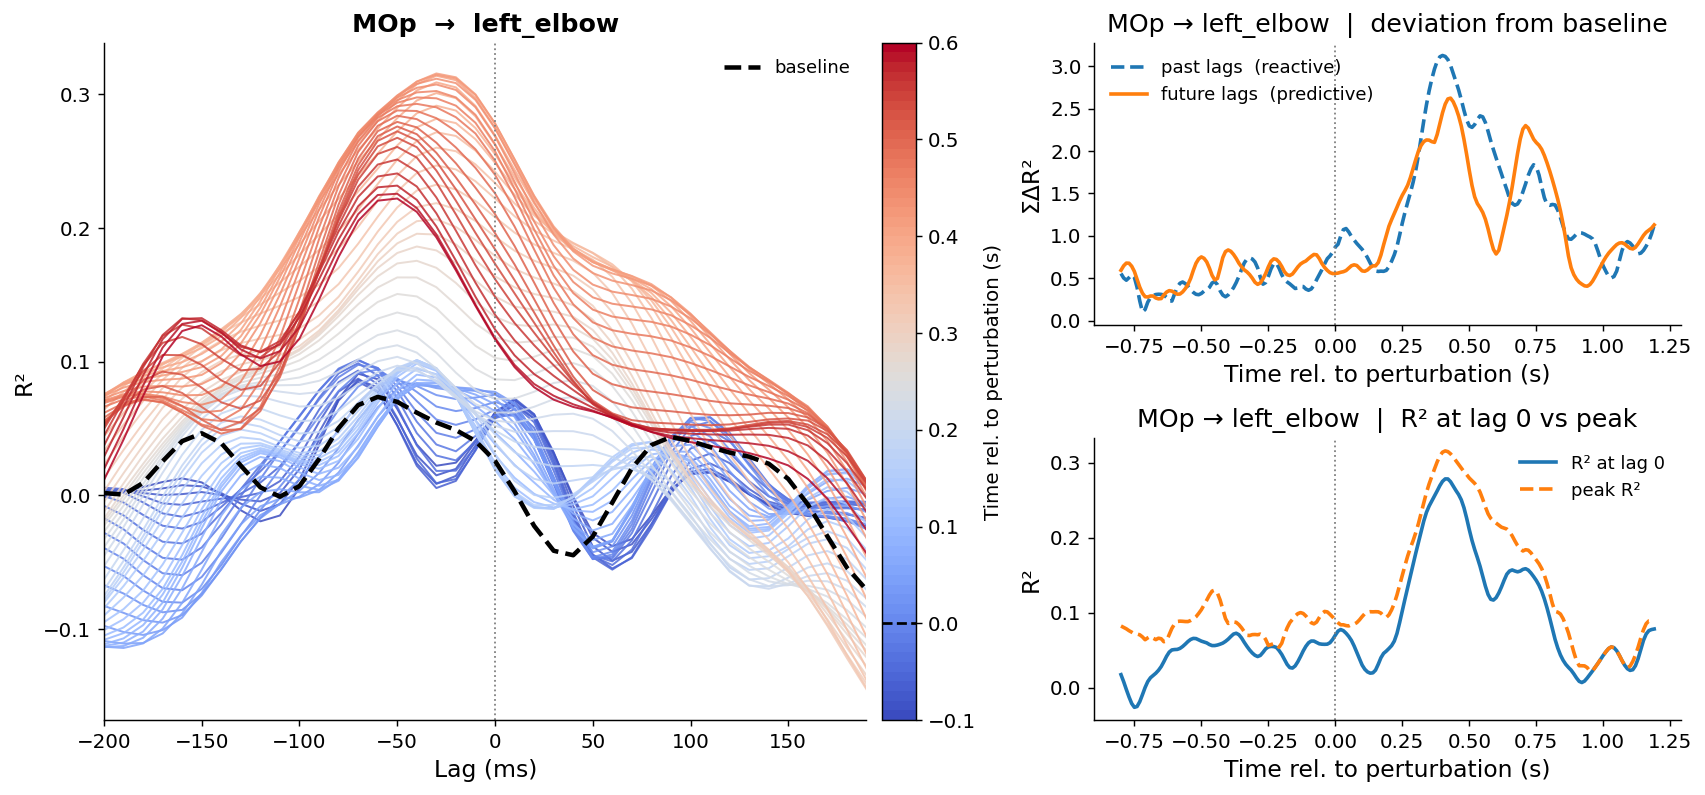

In [57]:
## ── Visualisation ────────────────────────────────────────────────────────────
# Time windows (seconds, relative to perturbation onset)
BASELINE_S  = (-1.0, -0.5)   # pre-perturbation baseline
SPAGHETTI_S = (-0.1,  0.6)   # coloured window for spaghetti plot

PRES_RC = {
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    14,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        130,
}

# ── Derived quantities ────────────────────────────────────────────────────────
all_t   = np.array(sorted(results.keys()))
lags_ms = _lags_bins * BIN_SIZE * 1000                      # lag axis in ms
t_0_idx = np.where(_lags_bins == 0)[0][0]                   # index of lag = 0

# Baseline: average R² curve over pre-perturbation bins
bl_mask       = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
baseline_mean = np.array([results[t].mean(-1) for t in all_t[bl_mask]]).mean(0)

# Spaghetti time range
sp_mask = (all_t >= SPAGHETTI_S[0]) & (all_t <= SPAGHETTI_S[1])
sp_t    = all_t[sp_mask]

# Past/future deviation from baseline (over all time bins)
def _deviation(curve, baseline):
    return np.sum(np.abs(curve - baseline))

past_dev   = np.array([_deviation(results[t].mean(-1)[:t_0_idx],   baseline_mean[:t_0_idx])   for t in all_t])
future_dev = np.array([_deviation(results[t].mean(-1)[t_0_idx:],   baseline_mean[t_0_idx:])   for t in all_t])
r2_at_lag0 = np.array([results[t].mean(-1)[t_0_idx]                                           for t in all_t])
peak_r2    = np.array([results[t].mean(-1).max()                                               for t in all_t])

# ── Figure ────────────────────────────────────────────────────────────────────
_cmap = mpl.colormaps["coolwarm"].resampled(len(sp_t))
_norm = mpl.colors.Normalize(vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1])
_sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

with mpl.rc_context(PRES_RC):
    fig = plt.figure(figsize=(13, 6), constrained_layout=True)
    gs  = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig,
                                width_ratios=[1.3, 1], height_ratios=[1, 1])

    ax_sp  = fig.add_subplot(gs[:, 0])   # spaghetti — spans both rows
    ax_dev = fig.add_subplot(gs[0, 1])   # deviation — top right
    ax_pk  = fig.add_subplot(gs[1, 1])   # R² at lag 0 + peak R² — bottom right

    # ── Spaghetti ─────────────────────────────────────────────────────────
    for t_s in sp_t:
        ax_sp.plot(lags_ms, results[t_s].mean(-1), color=_cmap(_norm(t_s)),
                   lw=1.1, alpha=0.85)

    ax_sp.plot(lags_ms, baseline_mean, color='k', lw=2.5, ls='--',
               zorder=10, label='baseline')
    ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
    ax_sp.set_xlabel('Lag (ms)')
    ax_sp.set_ylabel('R²')
    ax_sp.set_xlim(lags_ms[0], lags_ms[-1])
    ax_sp.set_title(f'{AREA}  →  {KEYPOINT}', fontweight='bold')
    ax_sp.legend(frameon=False, fontsize=10)

    cb = fig.colorbar(_sm, ax=ax_sp, pad=0.02)
    cb.set_label('Time rel. to perturbation (s)', fontsize=11)
    cb.ax.axhline(0, color='k', lw=1.5, ls='--')

    # ── Deviation from baseline ───────────────────────────────────────────
    ax_dev.plot(all_t, past_dev,   ls='--', lw=2, label='past lags  (reactive)')
    ax_dev.plot(all_t, future_dev, ls='-',  lw=2, label='future lags  (predictive)')
    ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
    ax_dev.set_xlabel('Time rel. to perturbation (s)')
    ax_dev.set_ylabel('ΣΔR²')
    ax_dev.set_title(f'{AREA} → {KEYPOINT}  |  deviation from baseline')
    ax_dev.legend(frameon=False, fontsize=10)

    # ── R² at lag 0 vs peak R² ────────────────────────────────────────────
    ax_pk.plot(all_t, r2_at_lag0, lw=2, label='R² at lag 0')
    ax_pk.plot(all_t, peak_r2,    lw=2, label='peak R²', ls='--')
    ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
    ax_pk.set_xlabel('Time rel. to perturbation (s)')
    ax_pk.set_ylabel('R²')
    ax_pk.set_title(f'{AREA} → {KEYPOINT}  |  R² at lag 0 vs peak')
    ax_pk.legend(frameon=False, fontsize=10)

    plt.show()

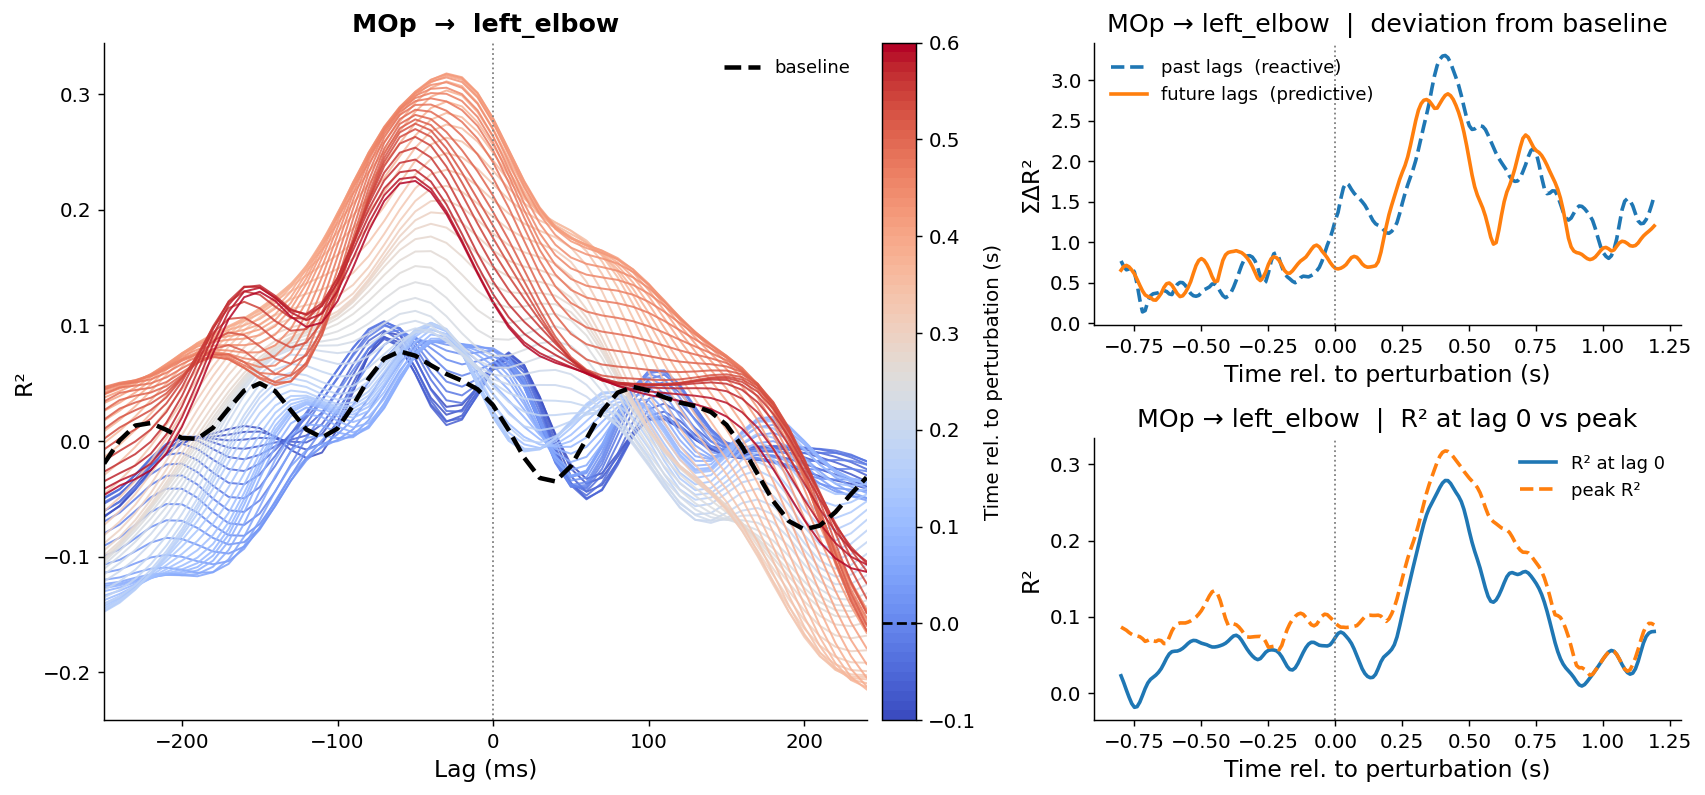

In [59]:
## ── Visualisation ────────────────────────────────────────────────────────────
# Time windows (seconds, relative to perturbation onset)
BASELINE_S  = (-1.0, -0.5)   # pre-perturbation baseline
SPAGHETTI_S = (-0.1,  0.6)   # coloured window for spaghetti plot

PRES_RC = {
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    14,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        130,
}

# ── Derived quantities ────────────────────────────────────────────────────────
all_t   = np.array(sorted(results.keys()))
lags_ms = _lags_bins * BIN_SIZE * 1000                      # lag axis in ms
t_0_idx = np.where(_lags_bins == 0)[0][0]                   # index of lag = 0

# Baseline: average R² curve over pre-perturbation bins
bl_mask       = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
baseline_mean = np.array([results[t].mean(-1) for t in all_t[bl_mask]]).mean(0)

# Spaghetti time range
sp_mask = (all_t >= SPAGHETTI_S[0]) & (all_t <= SPAGHETTI_S[1])
sp_t    = all_t[sp_mask]

# Past/future deviation from baseline (over all time bins)
def _deviation(curve, baseline):
    return np.sum(np.abs(curve - baseline))

past_dev   = np.array([_deviation(results[t].mean(-1)[:t_0_idx],   baseline_mean[:t_0_idx])   for t in all_t])
future_dev = np.array([_deviation(results[t].mean(-1)[t_0_idx:],   baseline_mean[t_0_idx:])   for t in all_t])
r2_at_lag0 = np.array([results[t].mean(-1)[t_0_idx]                                           for t in all_t])
peak_r2    = np.array([results[t].mean(-1).max()                                               for t in all_t])

# ── Figure ────────────────────────────────────────────────────────────────────
_cmap = mpl.colormaps["coolwarm"].resampled(len(sp_t))
_norm = mpl.colors.Normalize(vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1])
_sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

with mpl.rc_context(PRES_RC):
    fig = plt.figure(figsize=(13, 6), constrained_layout=True)
    gs  = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig,
                                width_ratios=[1.3, 1], height_ratios=[1, 1])

    ax_sp  = fig.add_subplot(gs[:, 0])   # spaghetti — spans both rows
    ax_dev = fig.add_subplot(gs[0, 1])   # deviation — top right
    ax_pk  = fig.add_subplot(gs[1, 1])   # R² at lag 0 + peak R² — bottom right

    # ── Spaghetti ─────────────────────────────────────────────────────────
    for t_s in sp_t:
        ax_sp.plot(lags_ms, results[t_s].mean(-1), color=_cmap(_norm(t_s)),
                   lw=1.1, alpha=0.85)

    ax_sp.plot(lags_ms, baseline_mean, color='k', lw=2.5, ls='--',
               zorder=10, label='baseline')
    ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
    ax_sp.set_xlabel('Lag (ms)')
    ax_sp.set_ylabel('R²')
    ax_sp.set_xlim(lags_ms[0], lags_ms[-1])
    ax_sp.set_title(f'{AREA}  →  {KEYPOINT}', fontweight='bold')
    ax_sp.legend(frameon=False, fontsize=10)

    cb = fig.colorbar(_sm, ax=ax_sp, pad=0.02)
    cb.set_label('Time rel. to perturbation (s)', fontsize=11)
    cb.ax.axhline(0, color='k', lw=1.5, ls='--')

    # ── Deviation from baseline ───────────────────────────────────────────
    ax_dev.plot(all_t, past_dev,   ls='--', lw=2, label='past lags  (reactive)')
    ax_dev.plot(all_t, future_dev, ls='-',  lw=2, label='future lags  (predictive)')
    ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
    ax_dev.set_xlabel('Time rel. to perturbation (s)')
    ax_dev.set_ylabel('ΣΔR²')
    ax_dev.set_title(f'{AREA} → {KEYPOINT}  |  deviation from baseline')
    ax_dev.legend(frameon=False, fontsize=10)

    # ── R² at lag 0 vs peak R² ────────────────────────────────────────────
    ax_pk.plot(all_t, r2_at_lag0, lw=2, label='R² at lag 0')
    ax_pk.plot(all_t, peak_r2,    lw=2, label='peak R²', ls='--')
    ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
    ax_pk.set_xlabel('Time rel. to perturbation (s)')
    ax_pk.set_ylabel('R²')
    ax_pk.set_title(f'{AREA} → {KEYPOINT}  |  R² at lag 0 vs peak')
    ax_pk.legend(frameon=False, fontsize=10)

    plt.show()

In [ ]:
## ── Future vs Past: direct lag-asymmetry (no baseline) ──────────────────────
#
# For each time bin t, split the R²-vs-lag curve at lag=0:
#   past_r2[t]   = mean R² over negative lags  (neural lags kin  → reactive)
#   future_r2[t] = mean R² over positive lags  (neural leads kin  → predictive)
#   asymmetry[t] = future_r2 - past_r2
#
# Positive asymmetry → neural activity predicts upcoming kinematics
# Negative asymmetry → neural activity reflects recent kinematics

past_mask   = _lags_bins < 0
future_mask = _lags_bins > 0

all_t = np.array(sorted(results.keys()))

past_r2   = np.array([results[t].mean(-1)[past_mask].mean()   for t in all_t])
future_r2 = np.array([results[t].mean(-1)[future_mask].mean() for t in all_t])
asymmetry = future_r2 - past_r2

print(f"Peak future R²  : {future_r2.max():.4f}  at t={all_t[future_r2.argmax()]:.2f} s")
print(f"Peak past R²    : {past_r2.max():.4f}  at t={all_t[past_r2.argmax()]:.2f} s")
print(f"Peak asymmetry  : {asymmetry.max():.4f}  at t={all_t[asymmetry.argmax()]:.2f} s")
print(f"Min  asymmetry  : {asymmetry.min():.4f}  at t={all_t[asymmetry.argmin()]:.2f} s")

with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)

    # ── top: past and future mean R² over time ────────────────────────────
    ax = axes[0]
    ax.plot(all_t, past_r2,   ls='--', lw=2, label='past lags  (reactive)')
    ax.plot(all_t, future_r2, ls='-',  lw=2, label='future lags  (predictive)')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_ylabel('Mean R²')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  mean R² by lag sign', fontweight='bold')
    ax.legend(frameon=False, fontsize=10)

    # ── bottom: asymmetry (future − past) ────────────────────────────────
    ax = axes[1]
    ax.plot(all_t, asymmetry, color='k', lw=2)
    ax.fill_between(all_t, asymmetry, 0,
                    where=(asymmetry > 0), color='steelblue', alpha=0.25, label='predictive')
    ax.fill_between(all_t, asymmetry, 0,
                    where=(asymmetry < 0), color='tomato',    alpha=0.25, label='reactive')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_ylabel('future R² − past R²')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_title('Lag asymmetry  (+ = predictive,  − = reactive)')
    ax.legend(frameon=False, fontsize=10)

    plt.show()